# Data Analysis
***

## Reading The Cleaned Data
In this notebook, we build on the outputs of the data cleaning stage. We load `stroke_data_cleaned.csv`, which already has the `id` column removed, missing `bmi` values imputed with the median, outliers in `avg_glucose_level` and `bmi` capped using the IQR method, and the continuous features (`age`, `avg_glucose_level`, `bmi`) standardized using Z-score scaling. The goal of this notebook is to move beyond basic exploration and statistically analyze the relationships between the available features and the target variable `stroke`, in order to identify the strongest risk factors ahead of model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

data = pd.read_csv('../Data/stroke_data_cleaned.csv')
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,1.051434,0,1,Yes,Private,Urban,2.058363,1.110872,formerly smoked,1
1,Female,0.786070,0,0,Yes,Self-employed,Rural,2.058363,-0.082921,never smoked,1
2,Male,1.626390,0,1,Yes,Private,Rural,0.148256,0.535043,never smoked,1
3,Female,0.255342,0,0,Yes,Private,Urban,2.058363,0.801890,smokes,1
4,Female,1.582163,1,0,Yes,Self-employed,Rural,2.058363,-0.658751,never smoked,1


## Dataset Overview
A quick recap of the cleaned dataset's structure and data types confirms that no missing values remain and that the continuous features have already been standardized (mean ≈ 0, std ≈ 1).

In [2]:
print('Dataset Shape:', data.shape)
print('\n========================================================================================')
print('Dataset Information:')
data.info()
print('\n========================================================================================')
print('Missing Values:')
print(data.isna().sum())

Dataset Shape: (5110, 11)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                5110 non-null   float64
 9   smoking_status     5110 non-null   str    
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 439.3 KB

Missing Values:
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type   

In [3]:
print('Statistical Summary of Numeric Features:')
data[['age', 'avg_glucose_level', 'bmi']].describe().T

Statistical Summary of Numeric Features:


,count,mean,std,min,25%,50%,75%,max
age,5110.0,4.449583e-17,1.000098,-1.908261,-0.806115,0.078432,0.786070,1.714845
avg_glucose_level,5110.0,-3.337187e-16,1.000098,-1.381335,-0.715150,-0.274339,0.394255,2.058363
bmi,5110.0,-6.674374e-17,1.000098,-2.582864,-0.686840,-0.082921,0.577176,2.473201


## Target Variable: Class Imbalance
Before analyzing relationships between features and stroke occurrence, it is essential to examine the distribution of the target variable itself. Healthcare datasets related to rare medical events, such as stroke, are commonly imbalanced, and this has direct implications for how the data should be split and modeled later on.

Stroke Class Counts:
stroke
0    4861
1     249
Name: count, dtype: int64

Stroke Class Percentages:
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


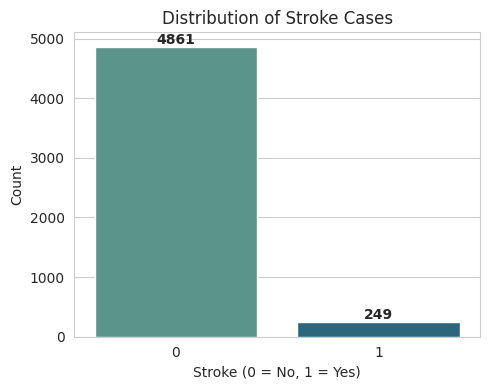

In [4]:
stroke_counts = data['stroke'].value_counts()
stroke_pct = data['stroke'].value_counts(normalize=True) * 100

print('Stroke Class Counts:')
print(stroke_counts)
print('\nStroke Class Percentages:')
print(stroke_pct.round(2))

plt.figure(figsize=(5, 4))
sns.countplot(x='stroke', data=data, hue='stroke', palette='crest', legend=False)
plt.title('Distribution of Stroke Cases')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
for i, v in enumerate(stroke_counts.sort_index()):
    plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** Only about 4.9% of the patients in the dataset experienced a stroke, confirming a strong class imbalance (roughly 20:1). This means accuracy alone will not be a reliable metric for the upcoming classification model, and techniques such as class weighting, resampling (e.g. SMOTE), or threshold tuning should be considered during model development.

## Numeric Features vs. Stroke
Since `age`, `avg_glucose_level`, and `bmi` are continuous variables, we compare their distributions between patients who had a stroke and those who did not. For each feature, we report the group means and run both a **t-test** (parametric) and a **Mann-Whitney U test** (non-parametric) to check whether the difference between groups is statistically significant, since the non-parametric test is more robust if the underlying distributions are skewed.

In [5]:
numeric_features = ['age', 'avg_glucose_level', 'bmi']
results = []

for col in numeric_features:
    group_no_stroke = data.loc[data['stroke'] == 0, col]
    group_stroke = data.loc[data['stroke'] == 1, col]

    t_stat, t_p = stats.ttest_ind(group_stroke, group_no_stroke, equal_var=False)
    u_stat, u_p = stats.mannwhitneyu(group_stroke, group_no_stroke, alternative='two-sided')

    results.append({
        'feature': col,
        'mean_no_stroke': group_no_stroke.mean(),
        'mean_stroke': group_stroke.mean(),
        't_stat': t_stat,
        't_pvalue': t_p,
        'mannwhitney_pvalue': u_p,
        'significant (p<0.05)': u_p < 0.05
    })

results_df = pd.DataFrame(results)
results_df

,feature,mean_no_stroke,mean_stroke,t_stat,t_pvalue,mannwhitney_pvalue,significant (p<0.05)
0,age,-0.055508,1.083640,29.686266,2.115685e-95,3.726635e-71,True
1,avg_glucose_level,-0.026175,0.510993,6.638101,1.802200e-10,4.068427e-09,True
2,bmi,-0.009664,0.188665,3.782994,1.881644e-04,2.751063e-04,True


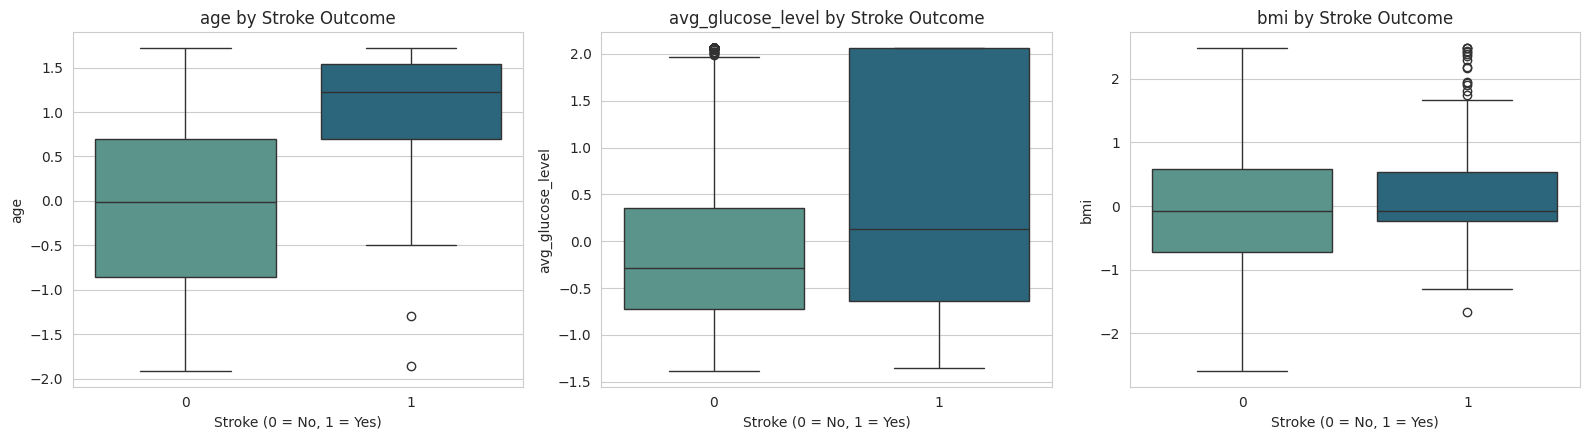

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(x='stroke', y=col, data=data, hue='stroke', palette='crest', legend=False, ax=ax)
    ax.set_title(f'{col} by Stroke Outcome')
    ax.set_xlabel('Stroke (0 = No, 1 = Yes)')
plt.tight_layout()
plt.show()

**Observation:** All three numeric features show a statistically significant difference (p < 0.05) between the two groups. Patients who had a stroke tend to have a noticeably higher standardized `age` and `avg_glucose_level`. The difference in `bmi` is statistically significant but visually much smaller, suggesting it is a weaker, though still relevant, predictor compared to age and glucose level.

## Categorical Features vs. Stroke
For categorical variables, a **Chi-Square test of independence** is used to check whether there is a statistically significant association between each feature and stroke occurrence. For every feature we display a cross-tabulation of stroke rates per category alongside the test results.

In [7]:
categorical_features = ['gender', 'hypertension', 'heart_disease', 'ever_married',
                        'work_type', 'Residence_type', 'smoking_status']

chi2_results = []

for col in categorical_features:
    contingency = pd.crosstab(data[col], data['stroke'])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    chi2_results.append({
        'feature': col,
        'chi2_stat': chi2,
        'p_value': p,
        'significant (p<0.05)': p < 0.05
    })

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
chi2_df

,feature,chi2_stat,p_value,significant (p<0.05)
2,heart_disease,90.259561,2.088785e-21,True
1,hypertension,81.605368,1.661622e-19,True
3,ever_married,58.923890,1.638902e-14,True
4,work_type,49.163512,5.397708e-10,True
6,smoking_status,29.147269,2.085400e-06,True
5,Residence_type,1.081637,2.983317e-01,False
0,gender,0.472587,7.895491e-01,False


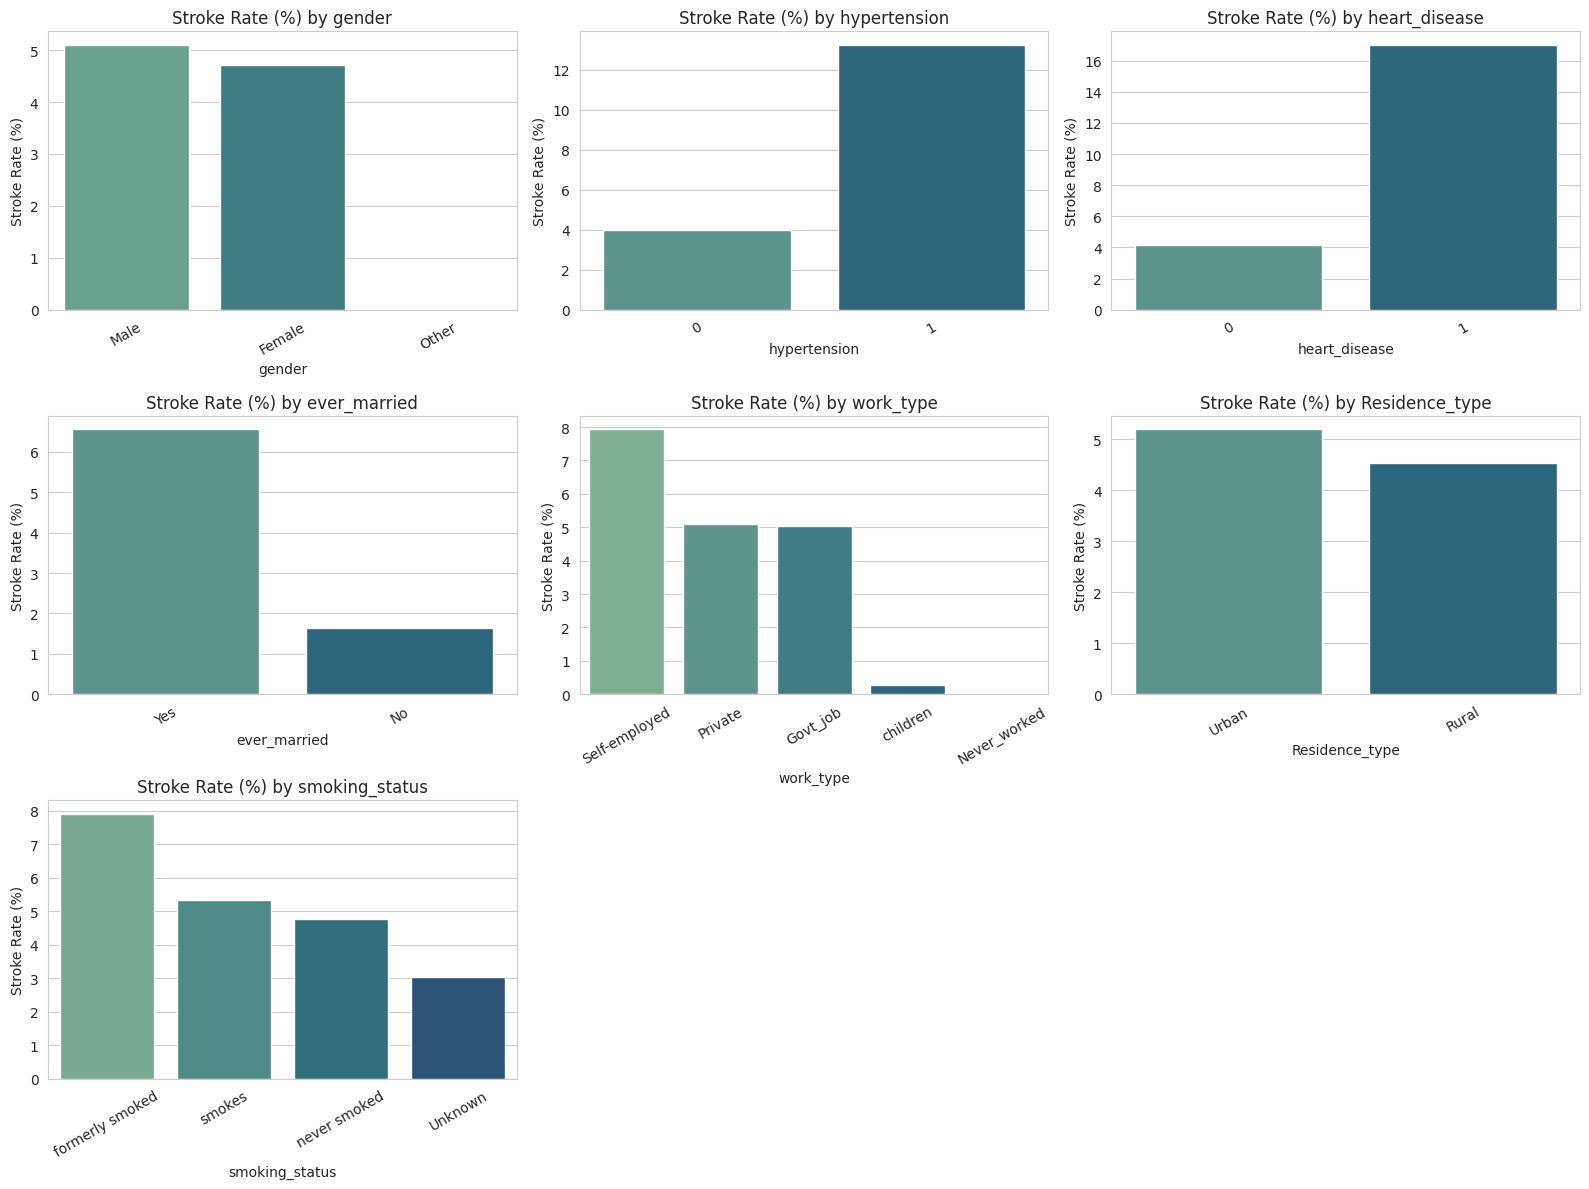

In [8]:
# Stroke rate (%) per category for each categorical feature
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    rate = data.groupby(col)['stroke'].mean().sort_values(ascending=False) * 100
    sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette='crest', legend=False, ax=axes[i])
    axes[i].set_title(f'Stroke Rate (%) by {col}')
    axes[i].set_ylabel('Stroke Rate (%)')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(len(categorical_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation:** `hypertension`, `heart_disease`, and `ever_married` show the strongest and most statistically significant associations with stroke occurrence, consistent with known medical risk factors. `work_type` also shows a significant association, largely driven by the `Self-employed` category, which correlates with an older average age. `gender`, `Residence_type` show weak or no significant association, suggesting they may add limited predictive value on their own.

## Correlation Analysis
To view all relationships together, the categorical features are label-encoded (for analysis purposes only) and combined with the standardized numeric features into a single correlation matrix.

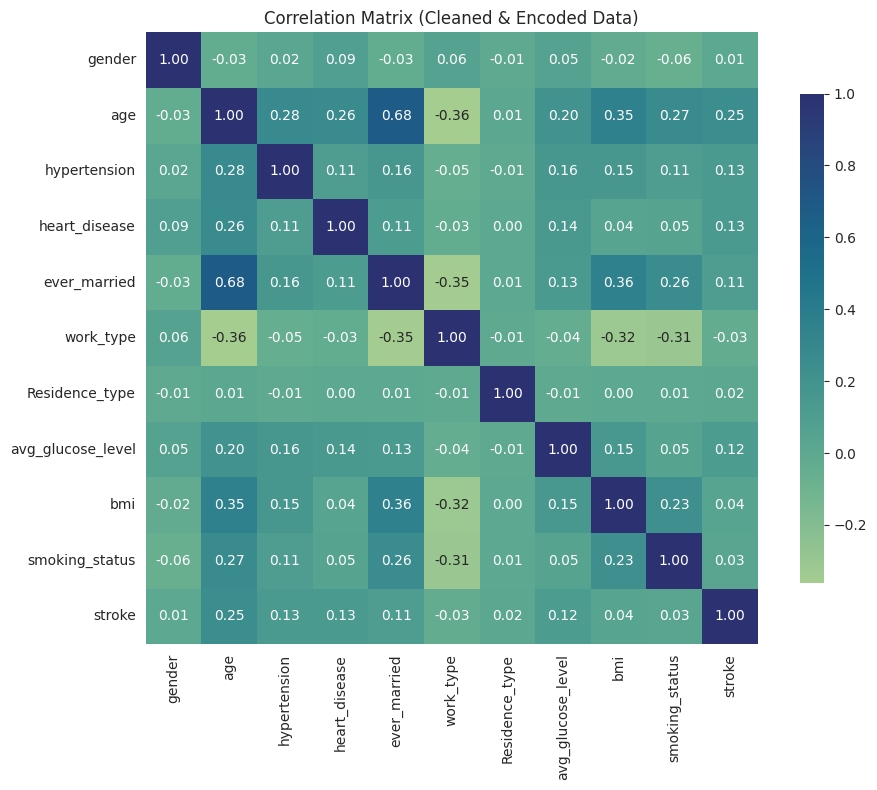

In [9]:
data_encoded = data.copy()
encoder = LabelEncoder()

for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    data_encoded[col] = encoder.fit_transform(data_encoded[col])

corr_matrix = data_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='crest', square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (Cleaned & Encoded Data)')
plt.tight_layout()
plt.show()

In [10]:
stroke_corr = corr_matrix['stroke'].drop('stroke').sort_values(ascending=False)
print('Feature Correlation with Stroke (sorted):')
stroke_corr

Feature Correlation with Stroke (sorted):


age                  0.245257
heart_disease        0.134914
hypertension         0.127904
avg_glucose_level    0.115652
ever_married         0.108340
bmi                  0.042700
smoking_status       0.028123
Residence_type       0.015458
gender               0.008929
work_type           -0.032316
Name: stroke, dtype: float64

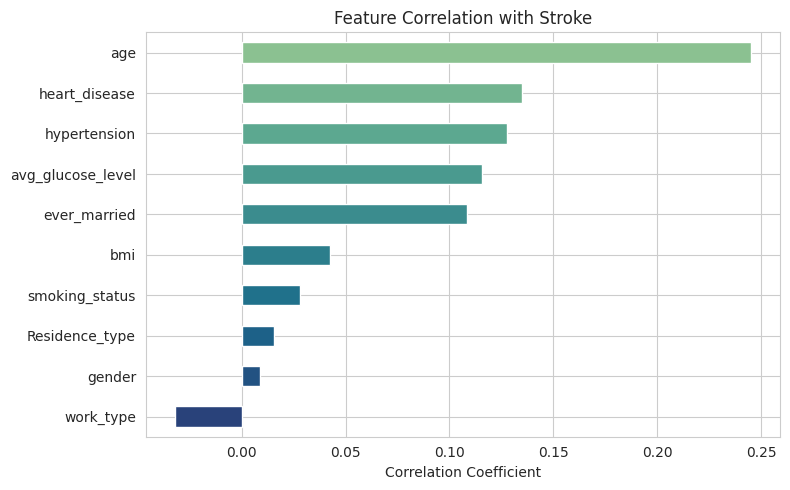

In [11]:
plt.figure(figsize=(8, 5))
stroke_corr.plot(kind='barh', color=sns.color_palette('crest', len(stroke_corr)))
plt.title('Feature Correlation with Stroke')
plt.xlabel('Correlation Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** `age` remains the strongest single predictor of stroke, followed by `heart_disease`, `avg_glucose_level`, `ever_married`, and `hypertension`. This is fully consistent with both the Chi-Square and t-test/Mann-Whitney results above, reinforcing that these are the most reliable features to prioritize for the predictive model.

## Combined Risk Factor Analysis
Medical risk factors rarely act in isolation. Here we examine how stroke rates change when combining two known risk factors, `hypertension` and `heart_disease`, and how stroke risk evolves across age groups.

In [12]:
risk_combo = data.groupby(['hypertension', 'heart_disease'])['stroke'].agg(['mean', 'count'])
risk_combo['stroke_rate_%'] = (risk_combo['mean'] * 100).round(2)
risk_combo = risk_combo.drop(columns='mean')
risk_combo

count  stroke_rate_%
hypertension heart_disease                      
0            0               4400           3.39
             1                212          16.04
1            0                434          12.21
             1                 64          20.31

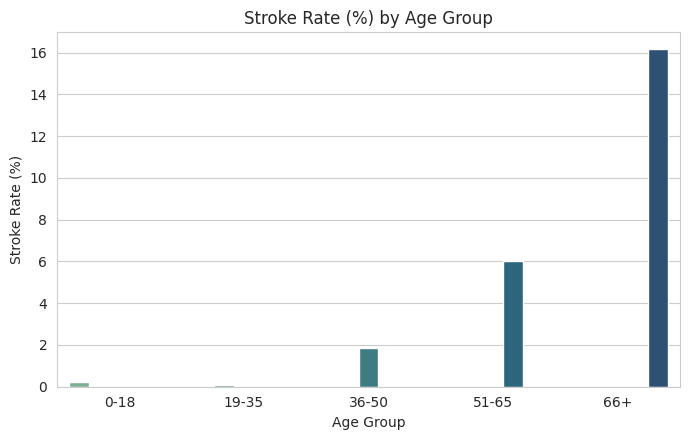

In [13]:
# Age groups based on the ORIGINAL (unstandardized) age scale for interpretability
raw_age = pd.read_csv('../Data/healthcare-dataset-stroke-data.csv')['age']
age_groups = pd.cut(raw_age, bins=[0, 18, 35, 50, 65, 82],
                     labels=['0-18', '19-35', '36-50', '51-65', '66+'])

age_risk = data.assign(age_group=age_groups.values).groupby('age_group', observed=True)['stroke'].mean() * 100

plt.figure(figsize=(7, 4.5))
sns.barplot(x=age_risk.index, y=age_risk.values, hue=age_risk.index, palette='crest', legend=False)
plt.title('Stroke Rate (%) by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Stroke Rate (%)')
plt.tight_layout()
plt.show()

**Observation:** Patients with both `hypertension` and `heart_disease` show a markedly higher stroke rate than patients with either condition alone or neither, indicating a compounding risk effect. Stroke rate also rises sharply with age, particularly after 50, reaffirming age as the single most influential risk factor in this dataset.

## Key Findings & Next Steps
- The dataset is **highly imbalanced** (≈4.9% stroke cases), which must be addressed during model development through class weighting, resampling, or an appropriate evaluation metric (e.g. recall, F1, ROC-AUC rather than accuracy).
- The strongest individual predictors of stroke are **age**, **heart_disease**, **avg_glucose_level**, **ever_married**, and **hypertension**, all statistically significant (p < 0.05) with medically consistent directions.
- **bmi**, **gender**, and **Residence_type** show weak or no significant relationship with stroke and are less reliable standalone predictors.
- Combined risk factors (e.g. hypertension **and** heart disease together) are associated with substantially higher stroke rates than either factor alone, suggesting potential value in interaction features during modeling.
- These findings will guide feature selection and preprocessing decisions in the next notebook, `4_Model_Development.ipynb`.